In [ ]:
from abc import abstractmethod
from typing import List, Callable

import numpy as np
from torch import Tensor
import torch
from torch import nn
from torch.nn import Module as TorchModule
from transformers import AutoTokenizer, AutoModelForCausalLM
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import SymmetricalLogLocator, MaxNLocator

load_dotenv()

class Module():
    def __init__(self, module_name: str, module_data: TorchModule) -> None:
        self.module_name = module_name
        self.module_data = module_data
        
    def get_weights(self) -> Tensor:
        if hasattr(self.module_data, "weight"):
            return self.module_data.weight.data.float().cpu().numpy().flatten()
        else:
            raise Exception(f"Module '{self.module_name}' does not have weights.")
        
    def has_weights(self) -> bool:
        return hasattr(self.module_data, "weight")
    

class Model():
    def __init__(self, model_name: str) -> None:
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.modules: List[Module] = []
        
    def load_model(self, token: str) -> None:
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, token=token)
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name, token=token)
        self.model.eval()
        
        self.modules: List[Module] = []
        for name, module in self.model.named_modules():
            layer = Module(name, module)
            self.modules.append(layer)
            
            
class Analyzer():
    def __init__(self) -> None:
        self.collected_weights: dict[Model, np.ndarray] = {}
        
    def collect_weights(self, model: Model, reduction: float) -> None:
        if not 0 < reduction <= 1:
            raise ValueError("Reduction must be in the interval (0, 1].")
        
        weights: np.ndarray = np.array([])
        for module in model.modules:
            if module.has_weights():
                layer_weights = module.get_weights()
                target_size = max(1, int(len(layer_weights) * reduction))
                indices = np.random.choice(len(layer_weights), size=target_size, replace=False)
                layer_weights = layer_weights[indices]
                weights = np.concatenate((weights, layer_weights))
            
        self.collected_weights[model] = weights    
    
    def get_all_weights(self, model: Model) -> np.ndarray:
        if model not in self.collected_weights:
            raise Exception(f"Weights not collected for model {model.model_name}. Operation aborted.")
        return self.collected_weights[model]
        
        
class Display():
    def __init__(self) -> None:
        pass
        
    def show_all_distribution(self, weights: np.ndarray, log_y: bool = False) -> None:
        plt.figure(figsize=(12, 6))
        plt.hist(weights, bins=100)
        plt.title("Distribution of weights from all layers")
        plt.xlabel("Weight Value")
        plt.ylabel("Frequency")
        if log_y:
            plt.yscale("log")
        plt.xscale("symlog", linthresh=3.0)
        ax = plt.gca()
        ax.xaxis.set_major_locator(MaxNLocator(nbins='auto', integer=False))
        plt.tight_layout()
        plt.show()
    
    
class Rule():
    def __init__(self, name: str, condition: Callable[[Module], bool], action: Callable[[Module], None]) -> None:
        self.name = name
        self.condition = condition
        self.action = action

    def evaluate(self, module: Module) -> bool:
        return self.condition(module)
    
    def apply(self, module: Module) -> None:
        self.action(module)
        
        
class Quantizer():
    def __init__(self) -> None:
        self.rules: List[Rule] = []
        
    def add_rule(self, rule: Rule) -> None:
        self.rules.append(rule)
        
    def add_rules(self, rules: List[Rule]) -> None:
        self.rules.extend(rules)
        
    def apply(self, model: Model) -> None:
        for module in model.modules:
            module._root_model = model.model

        for module in model.modules:
            for rule in self.rules:
                if rule.evaluate(module):
                    rule.apply(module)
                    

def _replace_module(root: nn.Module, name: str, new_mod: nn.Module) -> None:
    parts = name.split(".")
    parent = root
    for part in parts[:-1]:
        parent = getattr(parent, part)
    setattr(parent, parts[-1], new_mod)

In [ ]:
class Int8Linear(nn.Module):
    def __init__(self, w_int8: torch.Tensor, scale: torch.Tensor, bias=None):
        super().__init__()
        self.register_buffer("weight", w_int8) 
        self.register_buffer("scale", scale)
        self.bias = bias

    def forward(self, x):
        w = self.weight.to(x.dtype) * self.scale 
        return nn.functional.linear(x, w, self.bias)

    
def action_quantize_int8(module: Module) -> None:
    """ 
        Replace nn.Linear with Int8Linear
    
        Uses basic quantization of remapping everything to int8 with no clustering optimizations.
    """
    mod = module.module_data
    if not isinstance(mod, nn.Linear):
        raise Exception(f"Module '{module.module_name}' is not an nn.Linear. Operation aborted.")

    w = mod.weight.data
    scale = (w.abs().max() / 127.0).to(torch.float16)
    w_int8 = (w / scale).round().clamp(-128, 127).to(torch.int8)

    new_mod = Int8Linear(w_int8, scale, mod.bias)

    _replace_module(module._root_model, module.module_name, new_mod)
    
    module.module_data = new_mod
    
    
def is_linear() ->  Callable[[Module], bool]:
    return lambda m: isinstance(m.module_data, nn.Linear)

def name_contains(substring: str) -> Callable[[Module], bool]:
    return lambda m: substring in m.module_name

def name_not_contains(substring: str) -> Callable[[Module], bool]:
    return lambda m: substring not in m.module_name

def is_type(t: type) -> Callable[[Module], bool]:
    return lambda m: isinstance(m.module_data, t)

def all_of(*conditions) -> Callable[[Module], bool]:
    return lambda m: all(c(m) for c in conditions)

def any_of(*conditions) -> Callable[[Module], bool]:
    return lambda m: any(c(m) for c in conditions)

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 634.08it/s, Materializing param=model.norm.weight]                              


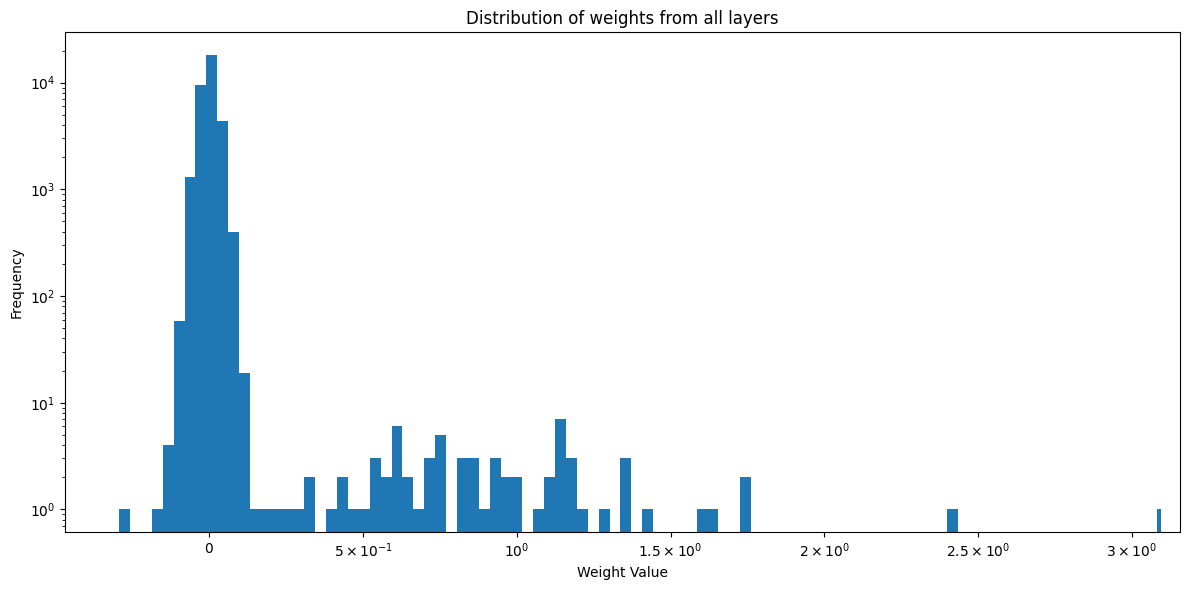

Exception: Module '' is not an nn.Linear. Operation aborted.

In [ ]:
model_name = "Qwen/Qwen2.5-3B-Instruct"
token = os.environ.get("HF_TOKEN")
if token is None:
    raise Exception("Token for HuggingFace is not set")

model = Model("Qwen/Qwen2.5-3B-Instruct")
model.load_model(token)

analyzer = Analyzer()
analyzer.collect_weights(model, reduction=0.00001)

display = Display()
display.show_all_distribution(analyzer.get_all_weights(model), log_y=True)

quantizer = Quantizer()
quantizer.add_rule(Rule("Quantize all linear layers", condition=all_of(is_linear(), name_not_contains("lm_head")), action=action_quantize_int8))
quantizer.apply(model)

analyzer.collect_weights(model, reduction=0.00001)
display.show_all_distribution(analyzer.get_all_weights(model), log_y=True)